# Xây dựng Mô hình Phân loại và Dự báo Rủi ro Khách hàng Vay vốn

**Notebook 03/07 - Data Cleaning (Làm sạch dữ liệu)**

---

**Mục tiêu:** Làm sạch bảng `application_flat` (do NB02 tạo trong PostgreSQL) — xử lý Missing Values, Duplicate, Outlier và giá trị sai logic — để dữ liệu sẵn sàng cho EDA.

**Input:** Bảng `application_flat` trong PostgreSQL (307.511 dòng x 148 cột)

**Output:** Bảng `application_flat_cleaned` trong PostgreSQL, kèm bảng tổng hợp chất lượng dữ liệu trước/sau khi làm sạch

**Pipeline:** Database Organization -> **Data Cleaning** -> EDA & Visualization

## 1. Giới thiệu

Notebook này biến `application_flat` — dữ liệu đã tích hợp từ PostgreSQL ở Notebook 02 — thành dữ liệu sạch, nhất quán và sẵn sàng cho EDA (Notebook 04). "Sạch" ở đây gồm bốn ý: không còn thiếu, không còn trùng lặp, không sai logic, đủ và rõ nghĩa.

Pipeline làm sạch của notebook này:

```
Đọc từ PostgreSQL -> Missing Values -> Duplicate -> Logic Validation
    -> Outlier -> Loại cột trùng lặp -> Đánh giá sau cleaning
    -> Lưu bảng sạch -> Notebook 04 (EDA)
```

**Khác một chỗ so với sơ đồ tổng quát của thầy** (`Missing -> Duplicate -> Outlier -> Logic Validation`): notebook này xử lý **Logic Validation trước Outlier**. Lý do: `bureau_sum_debt` và `credit_card_avg_balance` vừa có giá trị âm sai logic vừa là cột tiền cần xử lý outlier. Nếu cap theo phân vị trước khi sửa giá trị âm, các giá trị âm sai logic sẽ lọt vào công thức tính phân vị 1%/99% và làm lệch ngưỡng cap một cách không kiểm soát. Sửa sai logic trước để đảm bảo bước Outlier ở Mục 7 chỉ tính toán trên dữ liệu đã đúng về mặt nghiệp vụ.

**Vì sao NB03 chỉ làm sạch một bảng, trong khi NB01 đã chỉ ra vấn đề ở nhiều bảng phụ?**

NB02 đã gom cả 5 bảng phụ (`bureau`, `previous_application`, `installments_payments`, `POS_CASH_balance`, `credit_card_balance`) về mức một dòng cho mỗi khách hàng, rồi `LEFT JOIN` thành `application_flat`. Vì vậy dữ liệu của cả 5 bảng phụ đã nằm sẵn trong `application_flat` dưới dạng các nhóm cột (`bureau_*`, `previous_*`, `installments_*`, `pos_cash_*`, `credit_card_*`). Làm sạch theo từng nhóm cột này chính là làm sạch theo từng bảng phụ, chỉ khác là làm ở mức đã tổng hợp thay vì mức từng dòng giao dịch thô. Nếu làm sạch từng bảng raw trước rồi mới join thì phải làm lại toàn bộ NB02, nên hướng "làm sạch sau khi join" hợp lý hơn với kiến trúc đã chọn.

Giới hạn cần nêu rõ: một số lỗi ở tầng raw đã bị NB02 gộp lại bằng `SUM`/`AVG` trước khi tới NB03. Ví dụ giá trị âm của `AMT_CREDIT_SUM_DEBT` ở từng dòng `bureau` đã bị `SUM` thành `bureau_sum_debt`. NB03 chỉ xử lý được **giá trị tổng đã gộp**, không xử lý được từng dòng raw gốc — đây là cái giá của kiến trúc "clean sau join" đã chọn, cần minh bạch thay vì mặc định là đã xử lý triệt để.

## 2. Đọc dữ liệu

Đoạn code bên dưới kết nối PostgreSQL bằng `psycopg2` và đọc bảng `application_flat` bằng `pandas.read_sql`, không đọc lại file CSV.

In [1]:
from pathlib import Path
import os
import io
import warnings

import numpy as np
import pandas as pd
import psycopg2
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

# Nếu chạy notebook từ thư mục notebooks/, quay về thư mục gốc dự án.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

load_dotenv(PROJECT_ROOT / ".env")

# Chỉ tắt các cảnh báo gây nhiễu, KHÔNG tắt toàn bộ bằng "ignore" chung
# (tắt toàn bộ từng nuốt mất ChainedAssignmentError của pandas 3 ở bản NB03 cũ).
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*pandas only supports SQLAlchemy.*")

conn = psycopg2.connect(
    host=os.getenv("DB_HOST", "localhost"),
    port=os.getenv("DB_PORT", "5432"),
    dbname=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
)

df = pd.read_sql("SELECT * FROM application_flat", conn)

print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])
print("Bộ nhớ sử dụng (MB):", round(df.memory_usage(deep=True).sum() / 1024**2, 1))

df.head()

Số dòng: 307511
Số cột: 148
Bộ nhớ sử dụng (MB): 386.2


,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,pos_cash_count,pos_cash_avg_dpd,pos_cash_max_dpd,pos_cash_oldest_month,pos_cash_latest_month,credit_card_count,credit_card_avg_balance,credit_card_max_balance,credit_card_avg_limit,credit_card_max_dpd
0,176112,0,Cash loans,F,N,N,0.0,108000.0,152820.0,15241.5,...,13.0,0.0,0.0,-28.0,-16.0,NaN,NaN,NaN,NaN,NaN
1,176113,0,Cash loans,F,Y,Y,1.0,225000.0,273636.0,32602.5,...,16.0,0.0,0.0,-88.0,-67.0,NaN,NaN,NaN,NaN,NaN
2,176114,0,Cash loans,M,N,N,0.0,180000.0,239850.0,25960.5,...,19.0,0.0,0.0,-69.0,-28.0,NaN,NaN,NaN,NaN,NaN
3,176115,0,Cash loans,F,N,Y,0.0,214555.5,873000.0,24138.0,...,43.0,0.0,0.0,-57.0,-2.0,NaN,NaN,NaN,NaN,NaN
4,176116,0,Cash loans,F,Y,N,0.0,270000.0,1035000.0,34335.0,...,7.0,0.0,0.0,-51.0,-45.0,8.0,0.0,0.0,84375.0,0.0


**Nhận xét:** Bảng `application_flat` đọc từ PostgreSQL đúng 307.511 dòng x 148 cột, khớp với bàn giao của NB02. Từ đây trở đi notebook chỉ làm việc với `df` đọc từ database, không quay lại CSV.

In [2]:
# Chup lai snapshot du lieu GOC de dung cho bang so sanh Truoc/Sau o Muc 9.
df_before_cleaning = df.copy()

## 3. Đánh giá chất lượng ban đầu

Với 148 cột, notebook không xử lý từng cột thủ công mà chia nhóm theo kiểu dữ liệu và theo mức độ missing, làm nền cho các bước xử lý theo nhóm ở Mục 4 trở đi. Đoạn code bên dưới thống kê kiểu dữ liệu.

In [3]:
dtype_summary = (
    df.dtypes
    .astype(str)
    .value_counts()
    .reset_index()
)
dtype_summary.columns = ["Kiểu dữ liệu", "Số cột"]
dtype_summary

,Kiểu dữ liệu,Số cột
0,float64,98
1,int64,34
2,str,16


Đoạn code bên dưới chia toàn bộ cột theo mức độ missing: dưới 5%, 5-30% và trên 30%.

In [4]:
missing_count = df.isna().sum()
missing_rate = missing_count / len(df) * 100

missing_summary = pd.DataFrame({
    "Cột": missing_count.index,
    "Số ô thiếu": missing_count.values,
    "Tỷ lệ thiếu (%)": missing_rate.values,
})

def missing_bucket(pct):
    if pct == 0:
        return "Không thiếu"
    if pct < 5:
        return "<5%"
    if pct < 30:
        return "5-30%"
    return ">30%"

missing_summary["Nhóm missing"] = missing_summary["Tỷ lệ thiếu (%)"].apply(missing_bucket)
missing_summary["Kiểu dữ liệu"] = missing_summary["Cột"].map(df.dtypes.astype(str))

bucket_overview = missing_summary["Nhóm missing"].value_counts()
print(bucket_overview)

missing_summary[missing_summary["Số ô thiếu"] > 0].sort_values("Tỷ lệ thiếu (%)", ascending=False).head(15)

Nhóm missing
Không thiếu    55
>30%           55
5-30%          28
<5%            10
Name: count, dtype: int64


,Cột,Số ô thiếu,Tỷ lệ thiếu (%),Nhóm missing,Kiểu dữ liệu
147,credit_card_max_dpd,220606,71.739222,>30%,float64
144,credit_card_avg_balance,220606,71.739222,>30%,float64
146,credit_card_avg_limit,220606,71.739222,>30%,float64
145,credit_card_max_balance,220606,71.739222,>30%,float64
143,credit_card_count,220606,71.739222,>30%,float64
62,commonarea_mode,214865,69.872297,>30%,float64
48,commonarea_avg,214865,69.872297,>30%,float64
76,commonarea_medi,214865,69.872297,>30%,float64
84,nonlivingapartments_medi,213514,69.432963,>30%,float64
70,nonlivingapartments_mode,213514,69.432963,>30%,float64


**Nhận xét:** 93/148 cột có missing, chia thành ba nhóm: dưới 5% có 10 cột, 5-30% có 28 cột, trên 30% có 55 cột. Nhóm trên 30% chủ yếu là hai loại cột:

- Nhóm cột summary từ NB02 (`credit_card_*`) — missing vì khách hàng thực sự không có lịch sử thẻ tín dụng, không phải dữ liệu bị hỏng.
- Nhóm cột nhà ở (`_avg`/`_medi`/`_mode`) — missing vì hồ sơ vay không kê khai thông tin nhà ở.

Mục 4 xử lý theo từng nhóm cột thay vì xử lý máy móc từng cột một.

Đoạn code bên dưới vẽ top 20 cột thiếu nhiều nhất để hình dung mức độ trước khi làm sạch.

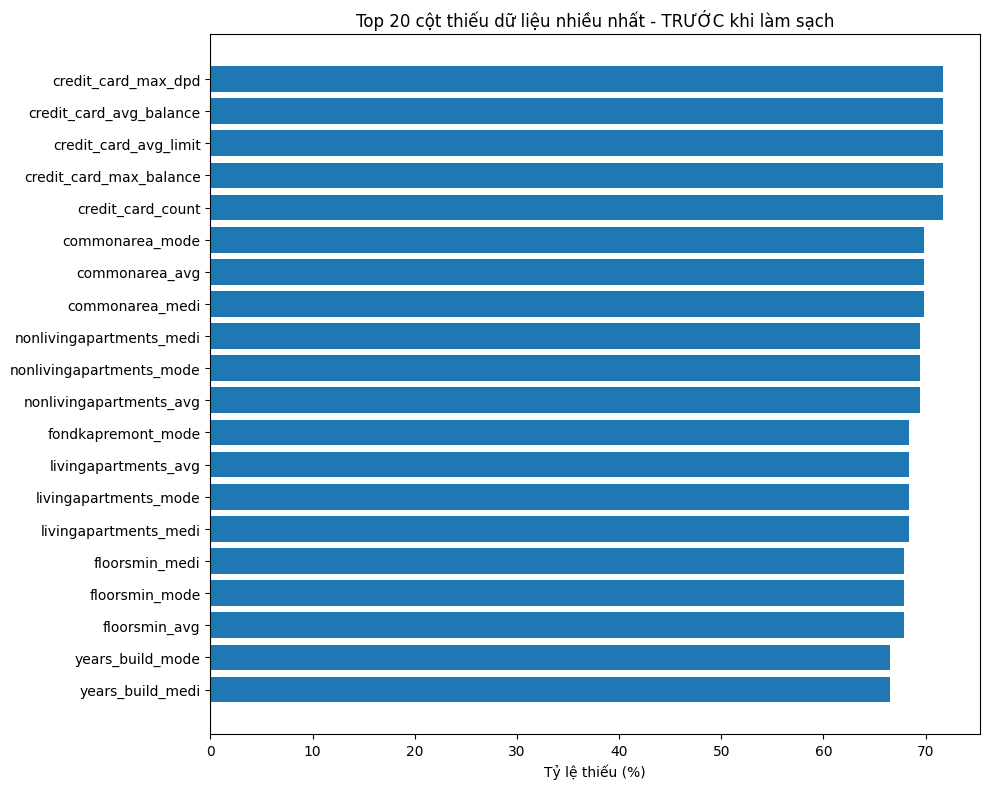

In [5]:
top_missing_before = missing_summary[missing_summary["Số ô thiếu"] > 0].sort_values(
    "Tỷ lệ thiếu (%)", ascending=False
).head(20)

plt.figure(figsize=(10, 8))
plt.barh(top_missing_before["Cột"], top_missing_before["Tỷ lệ thiếu (%)"])
plt.gca().invert_yaxis()
plt.xlabel("Tỷ lệ thiếu (%)")
plt.title("Top 20 cột thiếu dữ liệu nhiều nhất - TRƯỚC khi làm sạch")
plt.tight_layout()
plt.show()

**Nhận xét:** Đứng đầu là nhóm `credit_card_*` (thiếu 71,7%) và các cột nhà ở (thiếu 48-70%). Đây là hai nhóm sẽ được xử lý ở Mục 4 theo cách khác nhau tuỳ ý nghĩa nghiệp vụ, không điền median/mean một cách máy móc.

In [6]:
# Ham dung chung ve Truoc/After cho moi buoc bien doi du lieu, tranh copy-paste code ve.
def plot_before_after(before, after, title, kind="hist", bins=50):
    """Ve mot cap bieu do Truoc/Sau cho cung mot cot du lieu."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    if kind == "hist":
        axes[0].hist(before.dropna(), bins=bins, color="tab:blue")
        axes[1].hist(after.dropna(), bins=bins, color="tab:orange")
    elif kind == "box":
        axes[0].boxplot(before.dropna())
        axes[1].boxplot(after.dropna())
    elif kind == "bar":
        before.value_counts(dropna=False).sort_index().plot(kind="bar", ax=axes[0], color="tab:blue")
        after.value_counts(dropna=False).sort_index().plot(kind="bar", ax=axes[1], color="tab:orange")

    axes[0].set_title(f"{title} - Trước")
    axes[1].set_title(f"{title} - Sau")
    plt.tight_layout()
    plt.show()

## 4. Xử lý Missing Values

### 4.1. Nhóm cột summary từ bảng phụ (`bureau_*`, `previous_*`, `installments_*`, `pos_cash_*`, `credit_card_*`)

**Vấn đề:** Sau `LEFT JOIN` ở NB02, khách hàng chưa từng có hồ sơ ở bảng phụ tương ứng sẽ có toàn bộ nhóm cột summary là `NULL`. Đây là **tín hiệu thật** (khách không có lịch sử), không phải dữ liệu bị mất.

**Bằng chứng:** đoạn code bên dưới đếm số dòng `NULL` của cột đếm (`*_count`) trong từng nhóm.

In [7]:
SUMMARY_GROUPS = {
    "bureau": ["bureau_count", "bureau_sum_credit", "bureau_sum_debt",
               "bureau_max_overdue", "bureau_avg_days_credit", "bureau_latest_days_credit"],
    "previous": ["previous_count", "previous_sum_credit", "previous_avg_credit",
                 "previous_avg_days_decision", "previous_latest_decision"],
    "installments": ["installments_count", "installments_sum_due", "installments_sum_paid",
                      "installments_avg_late", "installments_max_late"],
    "pos_cash": ["pos_cash_count", "pos_cash_avg_dpd", "pos_cash_max_dpd",
                 "pos_cash_oldest_month", "pos_cash_latest_month"],
    "credit_card": ["credit_card_count", "credit_card_avg_balance", "credit_card_max_balance",
                    "credit_card_avg_limit", "credit_card_max_dpd"],
}

no_history_report = []
for group_name, cols in SUMMARY_GROUPS.items():
    count_col = cols[0]
    no_history = df[count_col].isna().sum()
    no_history_report.append({
        "Nhóm": group_name,
        "Cột đếm": count_col,
        "Số khách không có lịch sử": int(no_history),
        "Tỷ lệ (%)": round(no_history / len(df) * 100, 2),
    })

pd.DataFrame(no_history_report)

,Nhóm,Cột đếm,Số khách không có lịch sử,Tỷ lệ (%)
0,bureau,bureau_count,44020,14.31
1,previous,previous_count,16454,5.35
2,installments,installments_count,15868,5.16
3,pos_cash,pos_cash_count,18067,5.88
4,credit_card,credit_card_count,220606,71.74


**Nhận xét:** `credit_card_*` thiếu tới 71,74% vì chỉ khoảng 28% khách hàng từng dùng thẻ tín dụng; các nhóm còn lại thiếu 5-16% theo đúng tỷ lệ khách chưa từng vay ở bảng phụ tương ứng. Đây là bằng chứng số liệu cho lý do "tín hiệu thật, không phải lỗi".

**Cách xử lý:** với cột đếm (`*_count`), điền `0` vì khách thực sự có 0 giao dịch. Với các cột tổng/trung bình/lớn nhất còn lại trong nhóm, **không điền median/mean** — điền vào sẽ bịa ra một lịch sử tín dụng không tồn tại. Thay vào đó, giữ nguyên `NaN` và thêm một cột **flag** đánh dấu khách có/không có lịch sử ở bảng phụ đó, để các bước sau (NB04, NB05) tự quyết định cách dùng.

**Lý do chọn cách này:** đúng với cảnh báo của thầy — thiếu ở đây là tín hiệu nghiệp vụ, không phải missing ngẫu nhiên; giữ `NaN` + flag minh bạch hơn là điền một giá trị giả rồi coi như "đã sạch".

In [8]:
# Tao cot flag TRUOC khi dien 0, vi sau khi dien thi khong con phan biet duoc "khong co lich su".
for group_name, cols in SUMMARY_GROUPS.items():
    count_col = cols[0]
    flag_col = f"has_{group_name}_history"
    df[flag_col] = df[count_col].notna().astype(int)

# Dien 0 cho rieng cot dem, giu nguyen NaN cho cac cot tong/trung binh/lon nhat.
for group_name, cols in SUMMARY_GROUPS.items():
    count_col = cols[0]
    df[count_col] = df[count_col].fillna(0)

# Kiem tra: cot dem khong con NaN, va tong so khach "khong co lich su" theo flag phai
# khop dung voi bang no_history_report o tren.
for group_name, cols in SUMMARY_GROUPS.items():
    count_col = cols[0]
    flag_col = f"has_{group_name}_history"
    assert df[count_col].isna().sum() == 0
    assert (df[flag_col] == 0).sum() == no_history_report[list(SUMMARY_GROUPS).index(group_name)]["Số khách không có lịch sử"]

print("Đã tạo 5 cột flag: ", [f"has_{g}_history" for g in SUMMARY_GROUPS])
print("Toàn bộ cột *_count không còn NaN.")

Đã tạo 5 cột flag:  ['has_bureau_history', 'has_previous_history', 'has_installments_history', 'has_pos_cash_history', 'has_credit_card_history']
Toàn bộ cột *_count không còn NaN.


### 4.2. `own_car_age` — cột đã có flag sẵn (`flag_own_car`)

**Vấn đề:** `own_car_age` thiếu 65,99%, cao nhất trong các cột không thuộc nhóm summary hay nhóm nhà ở.

**Bằng chứng:** đối chiếu với `flag_own_car`.

In [9]:
car_check = df.groupby("flag_own_car")["own_car_age"].agg(so_dong="size", so_dong_co_gia_tri="count")
car_check

,so_dong,so_dong_co_gia_tri
flag_own_car,,
N,202924,0
Y,104587,104582


**Nhận xét:** `own_car_age` chỉ có giá trị khi `flag_own_car = 'Y'`; toàn bộ 202.924 khách có `flag_own_car = 'N'` đều `NULL` ở `own_car_age`. Đây là missing hoàn toàn do nghiệp vụ (không có xe thì không có tuổi xe), giống hệt lý do của nhóm `credit_card_*`.

**Cách xử lý:** không điền giá trị nào cho `own_car_age`. Cột `flag_own_car` đã có sẵn trong dữ liệu và đóng đúng vai trò flag, nên không cần tạo thêm cột mới. Giữ nguyên `NaN` để không bịa ra tuổi xe cho người không có xe.

### 4.3. Số lần hỏi tín dụng (`amt_req_credit_bureau_*`)

**Vấn đề:** 6 cột đếm số lần Credit Bureau bị hỏi về khách hàng (theo giờ/ngày/tuần/tháng/quý/năm) đều thiếu 13,50% cùng lúc.

**Cách xử lý:** đây là các cột đếm số lần, nên áp cùng logic với cột đếm của nhóm summary ở Mục 4.1 — điền `0` vì không có bản ghi hỏi tín dụng nào được tính, không phải dữ liệu bị mất.

In [10]:
CREDIT_BUREAU_ENQUIRY_COLS = [
    "amt_req_credit_bureau_hour", "amt_req_credit_bureau_day", "amt_req_credit_bureau_week",
    "amt_req_credit_bureau_mon", "amt_req_credit_bureau_qrt", "amt_req_credit_bureau_year",
]

missing_before_enquiry = df[CREDIT_BUREAU_ENQUIRY_COLS].isna().sum().sum()
df[CREDIT_BUREAU_ENQUIRY_COLS] = df[CREDIT_BUREAU_ENQUIRY_COLS].fillna(0)

assert df[CREDIT_BUREAU_ENQUIRY_COLS].isna().sum().sum() == 0
print("Số ô đã điền 0:", int(missing_before_enquiry))

Số ô đã điền 0: 249114


### 4.4. Ba điểm nguồn ngoài `ext_source_1/2/3`

**Vấn đề:** `ext_source_1` thiếu 56,38%, `ext_source_2` thiếu 0,21%, `ext_source_3` thiếu 19,83%.

**Lý do giữ và cách xử lý:** cả ba đều là biến numeric liên tục và là nhóm tương quan mạnh nhất với `TARGET` trong toàn bộ bảng (ghi nhận ở NB01) — **không được xoá dù thiếu nhiều**. Vì thiếu ở đây không gắn với một lý do nghiệp vụ rõ ràng như các nhóm trên (không phải "không có lịch sử"), notebook điền theo **median** của từng cột, cách xử lý numeric tiêu chuẩn, để giữ được cột dùng cho mô hình mà không bịa thêm flag không cần thiết.

In [11]:
EXT_SOURCE_COLS = ["ext_source_1", "ext_source_2", "ext_source_3"]

ext_source_before = df[EXT_SOURCE_COLS].isna().sum()

for col in EXT_SOURCE_COLS:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

assert df[EXT_SOURCE_COLS].isna().sum().sum() == 0
pd.DataFrame({"Số ô đã điền median": ext_source_before})

,Số ô đã điền median
ext_source_1,173378
ext_source_2,660
ext_source_3,60965


### 4.5. Nhóm cột nhà ở (numeric `_avg`, `totalarea_mode`, và các cột chữ `_mode`)

**Vấn đề:** 47 cột mô tả đặc điểm căn hộ/toà nhà (`apartments_avg`, `basementarea_avg`,... và các cột chữ `fondkapremont_mode`, `housetype_mode`, `wallsmaterial_mode`, `emergencystate_mode`) thiếu từ 47% đến 70%, do hồ sơ vay không kê khai thông tin nhà ở. Đây là nhóm có tương quan với `TARGET` yếu nhất bảng.

**Cách xử lý:** với cột numeric (14 cột `_avg` giữ lại + `totalarea_mode`), điền **median**. Với cột chữ (`occupation_type` và 4 cột `_mode` dạng chữ), điền `"Unknown"` thay vì mode — vì thiếu ở mức 31-68% là quá cao để coi một giá trị xuất hiện nhiều nhất là đại diện hợp lý cho toàn bộ phần thiếu; `"Unknown"` giữ đây là một nhóm riêng, trung thực hơn là gán bừa vào nhóm phổ biến nhất.

In [12]:
HOUSING_NUMERIC_KEEP = [
    "apartments_avg", "basementarea_avg", "years_beginexpluatation_avg", "years_build_avg",
    "commonarea_avg", "elevators_avg", "entrances_avg", "floorsmax_avg", "floorsmin_avg",
    "landarea_avg", "livingapartments_avg", "livingarea_avg", "nonlivingapartments_avg",
    "nonlivingarea_avg", "totalarea_mode",
]
HIGH_MISSING_TEXT_COLS = [
    "occupation_type", "fondkapremont_mode", "housetype_mode",
    "wallsmaterial_mode", "emergencystate_mode",
]

housing_numeric_before = df[HOUSING_NUMERIC_KEEP].isna().sum().sum()
for col in HOUSING_NUMERIC_KEEP:
    df[col] = df[col].fillna(df[col].median())

text_before = df[HIGH_MISSING_TEXT_COLS].isna().sum().sum()
for col in HIGH_MISSING_TEXT_COLS:
    df[col] = df[col].fillna("Unknown")

assert df[HOUSING_NUMERIC_KEEP].isna().sum().sum() == 0
assert df[HIGH_MISSING_TEXT_COLS].isna().sum().sum() == 0
print("Số ô numeric nhà ở đã điền median:", int(housing_numeric_before))
print("Số ô chữ đã điền 'Unknown':", int(text_before))

Số ô numeric nhà ở đã điền median: 2664511
Số ô chữ đã điền 'Unknown': 763079


### 4.6. Các cột missing thấp còn lại (dưới 5%)

**Vấn đề:** `name_type_suite` (chữ) và một số cột numeric (`obs_30_cnt_social_circle`, `def_30_cnt_social_circle`, `obs_60_cnt_social_circle`, `def_60_cnt_social_circle`, `amt_goods_price`, `amt_annuity`, `cnt_fam_members`, `days_last_phone_change`) thiếu dưới 0,5%.

**Cách xử lý:** áp quy tắc chuẩn — numeric điền **median**, cột chữ điền **mode** — vì tỷ lệ thiếu quá nhỏ nên không ảnh hưởng đáng kể tới phân phối dù chọn cách điền nào.

In [13]:
LOW_MISSING_NUMERIC_COLS = [
    "obs_30_cnt_social_circle", "def_30_cnt_social_circle",
    "obs_60_cnt_social_circle", "def_60_cnt_social_circle",
    "amt_goods_price", "amt_annuity", "cnt_fam_members", "days_last_phone_change",
]
LOW_MISSING_TEXT_COLS = ["name_type_suite"]

low_missing_before = df[LOW_MISSING_NUMERIC_COLS + LOW_MISSING_TEXT_COLS].isna().sum().sum()

for col in LOW_MISSING_NUMERIC_COLS:
    df[col] = df[col].fillna(df[col].median())

for col in LOW_MISSING_TEXT_COLS:
    df[col] = df[col].fillna(df[col].mode(dropna=True)[0])

assert df[LOW_MISSING_NUMERIC_COLS + LOW_MISSING_TEXT_COLS].isna().sum().sum() == 0
print("Số ô đã điền (median/mode):", int(low_missing_before))

Số ô đã điền (median/mode): 5669


### 4.7. Kiểm tra tổng thể sau khi xử lý Missing Values

Sau các bước trên, `NaN` còn lại trong dữ liệu chỉ nên xuất hiện ở ba nhóm đã **cố ý** giữ nguyên: `own_car_age`, 21 cột tổng/trung bình/lớn nhất trong 5 nhóm summary ở Mục 4.1, và 28 cột nhà ở dạng `_medi`/`_mode` sẽ bị loại bỏ vì trùng lặp ở Mục 8 (chưa xử lý ở đây vì đằng nào cũng sẽ bỏ, không cần điền median cho cột sắp xoá).

In [14]:
HOUSING_TRIO_BASES_TEMP = [
    "apartments", "basementarea", "years_beginexpluatation", "years_build",
    "commonarea", "elevators", "entrances", "floorsmax", "floorsmin",
    "landarea", "livingapartments", "livingarea", "nonlivingapartments", "nonlivingarea",
]
COLUMNS_TO_DROP_LATER = {f"{base}_medi" for base in HOUSING_TRIO_BASES_TEMP} | {
    f"{base}_mode" for base in HOUSING_TRIO_BASES_TEMP
}

EXPECTED_REMAINING_NA_COLS = {"own_car_age"} | COLUMNS_TO_DROP_LATER | {
    col for cols in SUMMARY_GROUPS.values() for col in cols[1:]
}

remaining_na = df.isna().sum()
remaining_na = remaining_na[remaining_na > 0]

unexpected_na_cols = set(remaining_na.index) - EXPECTED_REMAINING_NA_COLS
assert not unexpected_na_cols, f"Còn cột missing ngoài dự kiến: {unexpected_na_cols}"

print("Số cột còn NaN sau xử lý:", len(remaining_na), "/ 148")
print("Tổng số ô còn thiếu:", int(remaining_na.sum()),
      f"({remaining_na.sum() / (df.shape[0] * df.shape[1]) * 100:.2f}% toàn bảng)")
remaining_na.sort_values(ascending=False)

Số cột còn NaN sau xử lý: 50 / 148
Tổng số ô còn thiếu: 6546554 (13.91% toàn bảng)


credit_card_avg_limit           220606
credit_card_max_dpd             220606
credit_card_avg_balance         220606
credit_card_max_balance         220606
commonarea_mode                 214865
commonarea_medi                 214865
nonlivingapartments_medi        213514
nonlivingapartments_mode        213514
livingapartments_mode           210199
livingapartments_medi           210199
floorsmin_medi                  208642
floorsmin_mode                  208642
years_build_mode                204488
years_build_medi                204488
own_car_age                     202929
landarea_mode                   182590
landarea_medi                   182590
basementarea_medi               179943
basementarea_mode               179943
nonlivingarea_mode              169682
nonlivingarea_medi              169682
elevators_medi                  163891
elevators_mode                  163891
apartments_mode                 156061
apartments_medi                 156061
entrances_mode           

**Bảng Cleaning Rule — xử lý Missing Values:**

| Nhóm cột | Số cột | Missing | Phương pháp | Lý do |
|---|---|---|---|---|
| `*_count` (5 nhóm summary) | 5 | 5,2-71,7% | Điền `0` | Khách thực sự có 0 giao dịch ở bảng phụ đó |
| Cột tổng/TB/lớn nhất còn lại của 5 nhóm summary | 21 | 5,2-71,7% | Giữ `NaN` + cột flag `has_<nhóm>_history` | Không có giao dịch nên không có giá trị thật; điền median/mean sẽ bịa lịch sử tín dụng không tồn tại |
| `own_car_age` | 1 | 66,0% | Giữ `NaN` (đã có `flag_own_car`) | Không có xe thì không có tuổi xe; flag có sẵn, không cần tạo thêm |
| `amt_req_credit_bureau_*` | 6 | 13,5% | Điền `0` | Cột đếm số lần hỏi tín dụng, không hỏi thì bằng 0 |
| `ext_source_1/2/3` | 3 | 0,2-56,4% | Điền median | Biến mạnh nhất với `TARGET`, không xoá; thiếu không rõ lý do nghiệp vụ nên dùng cách numeric chuẩn |
| Nhà ở - numeric giữ lại (`_avg` + `totalarea_mode`) | 15 | 48,3-69,9% | Điền median | Numeric liên tục, thiếu do hồ sơ không kê khai |
| Nhà ở - chữ + `occupation_type` | 5 | 31,3-68,4% | Điền `"Unknown"` | Thiếu quá cao để dùng mode đại diện, giữ thành nhóm riêng |
| Numeric thiếu <5% | 8 | <0,5% | Điền median | Thiếu ít, không đáng ảnh hưởng phân phối |
| Chữ thiếu <5% | 1 | 0,4% | Điền mode | Thiếu ít, không đáng ảnh hưởng phân phối |

Sau Mục 4, dữ liệu vẫn còn `NaN` ở `own_car_age` và 21 cột tổng/TB/lớn nhất của nhóm summary — đây là lựa chọn có chủ đích, không phải sót, và đều có cột flag hoặc cột gốc (`flag_own_car`) đi kèm để phân biệt.

## 5. Xử lý Duplicate

NB01 đã ghi nhận cả 6 bảng phụ và `application_train` không có dòng trùng lặp, và `application_flat` có khoá duy nhất trên `sk_id_curr` (đã kiểm chứng ở NB02 Mục 7.1). Về lý thuyết `application_flat` không còn trùng lặp, nhưng đoạn code bên dưới vẫn chạy lại kiểm tra thay vì giả định.

In [15]:
duplicate_rows = df.duplicated().sum()
duplicate_ids = df["sk_id_curr"].duplicated().sum()

duplicate_report = pd.DataFrame([
    {"Kiểm tra": "Duplicate toàn dòng", "Số lượng": int(duplicate_rows)},
    {"Kiểm tra": "Duplicate theo sk_id_curr", "Số lượng": int(duplicate_ids)},
])

if duplicate_rows > 0:
    rows_before = len(df)
    df = df.drop_duplicates()
    print(f"Đã loại {rows_before - len(df)} dòng trùng lặp, còn lại {len(df)} dòng.")
else:
    print("Không có dòng nào bị loại, giữ nguyên", len(df), "dòng.")

duplicate_report

Không có dòng nào bị loại, giữ nguyên 307511 dòng.


,Kiểm tra,Số lượng
0,Duplicate toàn dòng,0
1,Duplicate theo sk_id_curr,0


**Nhận xét:** Cả hai kiểm tra đều trả về 0, xác nhận lại đúng như dự đoán từ NB01/NB02 — `application_flat` không có duplicate toàn dòng lẫn duplicate theo khoá khách hàng.

## 6. Xử lý giá trị sai logic

### 6.1. `days_employed = 365243`

**Vấn đề:** NB01 đã ghi nhận `DAYS_EMPLOYED` có giá trị `365243` (~1000 năm làm việc), là mã đặc biệt không hợp lý về nghiệp vụ chứ không phải số ngày thật.

**Bằng chứng:**

In [16]:
days_employed_special = (df["days_employed"] == 365243).sum()
print("Số dòng days_employed = 365243:", int(days_employed_special))
print("Tỷ lệ:", round(days_employed_special / len(df) * 100, 2), "%")

Số dòng days_employed = 365243: 55374
Tỷ lệ: 18.01 %


**Cách xử lý:** thêm cột flag `days_employed_anom` đánh dấu các dòng có mã đặc biệt này (bản thân giá trị 365243 lặp lại y hệt ở hơn 18% dòng là một tín hiệu có thể hữu ích cho mô hình), sau đó đưa `days_employed` về `NaN` và điền bằng median của các giá trị hợp lệ còn lại.

**Lý do:** dùng **phép gán tường minh** (`df['days_employed'] = ...`) thay vì `replace(..., inplace=True)` theo cột, vì pandas 3 bật Copy-on-Write khiến cú pháp `inplace=True` không ghi được vào DataFrame gốc — đây là lỗi đã từng làm hỏng bản NB03 cũ một cách âm thầm.

In [17]:
df["days_employed_anom"] = (df["days_employed"] == 365243).astype(int)

days_employed_median = df.loc[df["days_employed"] != 365243, "days_employed"].median()
df["days_employed"] = df["days_employed"].replace(365243, np.nan)
df["days_employed"] = df["days_employed"].fillna(days_employed_median)

assert (df["days_employed"] == 365243).sum() == 0
assert df["days_employed"].isna().sum() == 0
print("Đã thay", int(days_employed_special), "dòng bằng median =", round(days_employed_median, 1))

Đã thay 55374 dòng bằng median = -1648.0


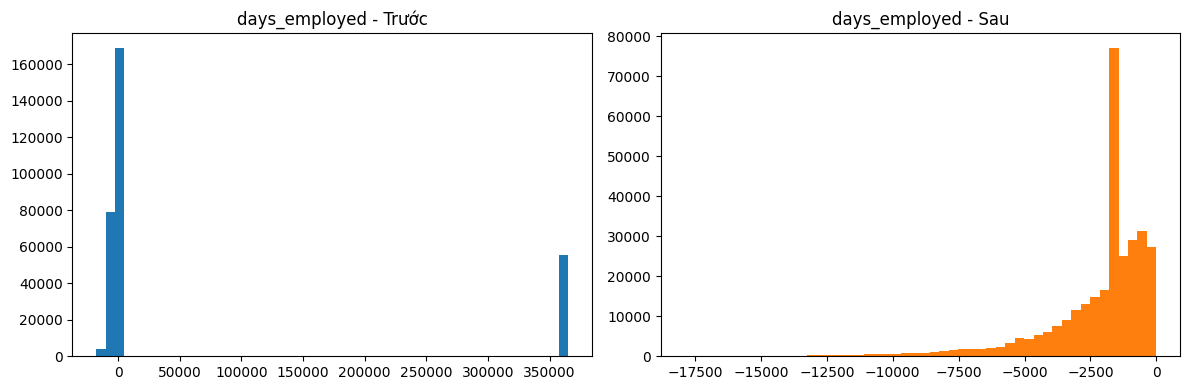

In [18]:
plot_before_after(
    df_before_cleaning["days_employed"], df["days_employed"],
    "days_employed", kind="hist",
)

**Nhận xét:** Ở biểu đồ Trước, cột dựng đứng bất thường tại mốc 365243 đã biến mất hoàn toàn ở biểu đồ Sau; phần phân phối còn lại (số ngày làm việc thật) không đổi.

### 6.2. `code_gender = 'XNA'`

**Vấn đề:** NB01 ghi nhận 4 dòng có `CODE_GENDER = 'XNA'`, giá trị không hợp lệ về giới tính.

In [19]:
gender_before = df["code_gender"].value_counts(dropna=False)
gender_before

code_gender
F      202448
M      105059
XNA         4
Name: count, dtype: int64

**Cách xử lý:** gộp 4 dòng `'XNA'` về nhóm phổ biến nhất (`'F'`). Số lượng chỉ 4/307.511 dòng (0,001%) nên không ảnh hưởng đáng kể tới phân bố giới tính, trong khi giữ nguyên `'XNA'` sẽ để lại một giá trị không có ý nghĩa nghiệp vụ trong cột phân loại.

In [20]:
xna_count = (df["code_gender"] == "XNA").sum()
df["code_gender"] = df["code_gender"].replace("XNA", "F")

assert (df["code_gender"] == "XNA").sum() == 0
print("Đã gộp", int(xna_count), "dòng XNA về nhóm F.")
df["code_gender"].value_counts()

Đã gộp 4 dòng XNA về nhóm F.


code_gender
F    202452
M    105059
Name: count, dtype: int64

### 6.3. Giá trị âm sai logic ở các cột đã gộp (`bureau_sum_debt`, `credit_card_avg_balance`)

**Vấn đề:** dư nợ (`bureau_sum_debt`) và số dư thẻ trung bình (`credit_card_avg_balance`) không thể âm về mặt nghiệp vụ, nhưng dữ liệu vẫn tồn tại giá trị âm ở mức tổng đã gộp từ NB02.

In [21]:
negative_report = pd.DataFrame([
    {
        "Cột": "bureau_sum_debt",
        "Số dòng âm": int((df["bureau_sum_debt"] < 0).sum()),
        "Giá trị nhỏ nhất": df["bureau_sum_debt"].min(),
    },
    {
        "Cột": "credit_card_avg_balance",
        "Số dòng âm": int((df["credit_card_avg_balance"] < 0).sum()),
        "Giá trị nhỏ nhất": df["credit_card_avg_balance"].min(),
    },
])
negative_report

,Cột,Số dòng âm,Giá trị nhỏ nhất
0,bureau_sum_debt,1296,-6.981558e+06
1,credit_card_avg_balance,28,-2.930233e+03


**Cách xử lý:** đưa các giá trị âm về `0`. Vì đây là số liệu đã bị `SUM`/`AVG` gộp từ nhiều dòng raw ở NB02, NB03 không truy ngược lại được dòng `bureau`/`credit_card_balance` gốc nào gây ra giá trị âm; số dòng bị ảnh hưởng chỉ khoảng 0,5% ở `bureau_sum_debt` (1.296/256.131 khách có lịch sử bureau) và 0,03% ở `credit_card_avg_balance` (28/86.905 khách có lịch sử thẻ) nên không đáng phải làm lại NB02 để sửa tận gốc. Bước này chạy **trước** khi xử lý Outlier ở Mục 7, để giá trị âm sai logic không lọt vào công thức tính phân vị cap.

In [22]:
negative_bureau_debt = (df["bureau_sum_debt"] < 0).sum()
negative_credit_card = (df["credit_card_avg_balance"] < 0).sum()

df["bureau_sum_debt"] = df["bureau_sum_debt"].clip(lower=0)
df["credit_card_avg_balance"] = df["credit_card_avg_balance"].clip(lower=0)

assert (df["bureau_sum_debt"] < 0).sum() == 0
assert (df["credit_card_avg_balance"] < 0).sum() == 0
print("Đã đưa về 0:", int(negative_bureau_debt), "dòng bureau_sum_debt và",
      int(negative_credit_card), "dòng credit_card_avg_balance.")

Đã đưa về 0: 1296 dòng bureau_sum_debt và 28 dòng credit_card_avg_balance.


**Nhận xét:** Sau xử lý, `bureau_sum_debt` và `credit_card_avg_balance` không còn giá trị âm nào, trong khi ý nghĩa nghiệp vụ (khách còn nợ bao nhiêu) không bị thổi phồng hay bóp méo vì chỉ đúng phần âm phi lý được đưa về 0.

## 7. Xử lý Outlier

**Vấn đề:** các cột tiền trong `application_flat` lệch phải rất nặng — phần lớn hồ sơ có giá trị vừa phải, nhưng một số ít hồ sơ có giá trị rất lớn so với trung vị.

**Bằng chứng:** đoạn code bên dưới dùng quy tắc IQR (`Q1 - 1.5*IQR`, `Q3 + 1.5*IQR`) để đếm số dòng vượt ngưỡng ở các cột tiền chính, đọc theo nhóm thay vì từng cột đơn lẻ. Bước này chạy sau Mục 6 nên hai cột `bureau_sum_debt`/`credit_card_avg_balance` đã không còn giá trị âm sai logic làm lệch ngưỡng phân vị.

In [23]:
MONEY_COLUMNS = [
    "amt_income_total", "amt_credit", "amt_annuity", "amt_goods_price",
    "bureau_sum_credit", "bureau_sum_debt",
    "previous_sum_credit", "previous_avg_credit",
    "installments_sum_due", "installments_sum_paid",
    "credit_card_avg_balance", "credit_card_max_balance", "credit_card_avg_limit",
]


def count_iqr_outliers(series):
    """Dem so gia tri nam ngoai [Q1 - 1.5*IQR, Q3 + 1.5*IQR]."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())


outlier_report = []
for col in MONEY_COLUMNS:
    n_outliers = count_iqr_outliers(df[col].dropna())
    outlier_report.append({
        "Cột": col,
        "Số dòng vượt IQR": n_outliers,
        "Tỷ lệ (%)": round(n_outliers / df[col].notna().sum() * 100, 2),
        "Trung vị": round(df[col].median(), 0),
        "Max": round(df[col].max(), 0),
    })

outlier_report_df = pd.DataFrame(outlier_report).sort_values("Tỷ lệ (%)", ascending=False)
outlier_report_df

,Cột,Số dòng vượt IQR,Tỷ lệ (%),Trung vị,Max
5,bureau_sum_debt,24324,9.50,184500.0,3.344983e+08
9,installments_sum_paid,26981,9.25,318627.0,2.553705e+07
8,installments_sum_due,25351,8.69,328372.0,2.327473e+07
6,previous_sum_credit,24399,8.38,427788.0,4.146113e+07
4,bureau_sum_credit,21991,8.35,961720.0,1.017958e+09
10,credit_card_avg_balance,6144,7.07,26794.0,9.286860e+05
12,credit_card_avg_limit,5927,6.82,149727.0,1.350000e+06
7,previous_avg_credit,18673,6.42,117450.0,4.050000e+06
3,amt_goods_price,14728,4.79,450000.0,4.050000e+06
0,amt_income_total,14035,4.56,147150.0,1.170000e+08


**Nhận xét:** tất cả các cột tiền đều có một tỷ lệ nhất định vượt ngưỡng IQR, và giá trị `Max` thường lớn hơn `Trung vị` nhiều lần. Đây là dấu hiệu lệch phải mạnh, đúng như NB01 đã ghi nhận đối với `AMT_CREDIT_SUM` ở bảng `bureau` (max gấp khoảng 4.661 lần trung vị).

Đúng như thầy lưu ý: **không phải outlier nào cũng nên xoá.** Phần lớn đây là khách vay lớn có thật chứ không phải lỗi nhập liệu, nên notebook không xoá dòng nào. Cách xử lý là **cap theo phân vị 1%-99%** (winsorize): giá trị vượt phân vị 99% được đưa về đúng phân vị 99%, giá trị dưới phân vị 1% được đưa về đúng phân vị 1%. Cách này giữ được toàn bộ số dòng và thứ hạng dữ liệu, chỉ giảm bớt ảnh hưởng của số ít giá trị cực đoan.

In [24]:
def cap_by_percentile(series, lower_q=0.01, upper_q=0.99):
    """Winsorize: dua gia tri ngoai [lower_q, upper_q] ve dung nguong phan vi."""
    lower, upper = series.quantile(lower_q), series.quantile(upper_q)
    return series.clip(lower=lower, upper=upper)


money_before_snapshot = df[MONEY_COLUMNS].copy()

for col in MONEY_COLUMNS:
    df[col] = cap_by_percentile(df[col])

# Kiem tra: sau cap, khong con gia tri nao vuot phan vi 1%/99% da tinh tren du lieu goc.
for col in MONEY_COLUMNS:
    lower, upper = money_before_snapshot[col].quantile(0.01), money_before_snapshot[col].quantile(0.99)
    assert df[col].dropna().between(lower, upper).all()

print("Đã cap", len(MONEY_COLUMNS), "cột tiền theo phân vị 1%-99%.")

Đã cap 13 cột tiền theo phân vị 1%-99%.


Đoạn code bên dưới minh hoạ Trước/Sau cho hai cột tiêu biểu: `amt_income_total` (bảng chính) và `bureau_sum_credit` (bảng phụ đã gộp).

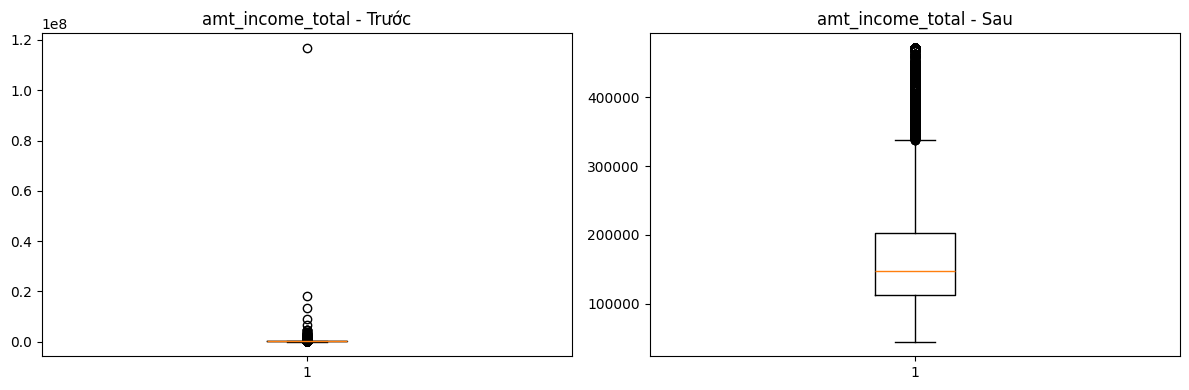

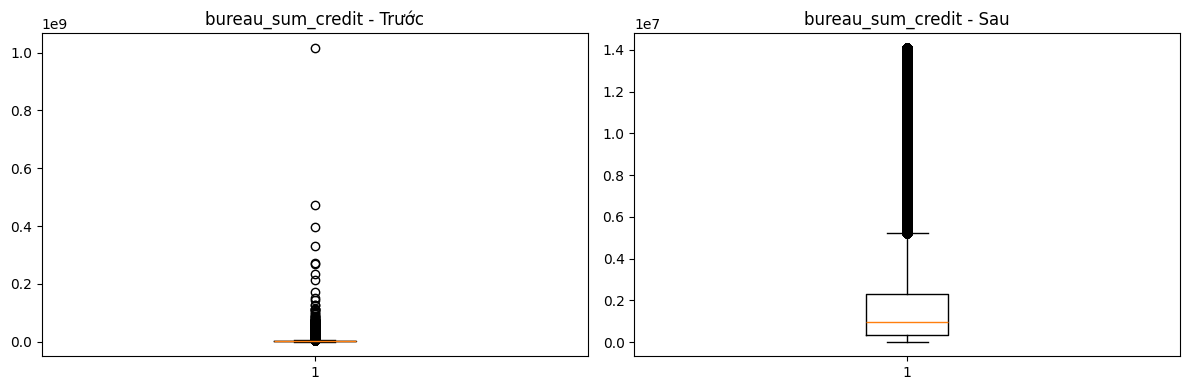

In [25]:
plot_before_after(
    money_before_snapshot["amt_income_total"], df["amt_income_total"],
    "amt_income_total", kind="box",
)
plot_before_after(
    money_before_snapshot["bureau_sum_credit"], df["bureau_sum_credit"],
    "bureau_sum_credit", kind="box",
)

**Nhận xét:** Sau khi cap, khoảng giá trị của cả hai cột thu hẹp lại rõ rệt (trục Sau không còn kéo dài do vài giá trị cực đoan), trong khi phần lớn dữ liệu (từ phân vị 1% đến 99%) giữ nguyên không đổi. Các cột tiền còn lại trong `MONEY_COLUMNS` được xử lý cùng phương pháp nên không lặp lại biểu đồ cho từng cột.

## 8. Loại cột trùng lặp / không cần thiết

**Vấn đề:** nhóm cột nhà ở có ba bản thống kê cho cùng một thuộc tính toà nhà — `_avg` (trung bình), `_medi` (trung vị), `_mode` (mode) — ví dụ `floorsmax_avg`, `floorsmax_medi`, `floorsmax_mode`. Ba bản này tương quan với `TARGET` gần như y hệt nhau vì cùng đo một đặc điểm, nên `_medi` và `_mode` là **cột trùng lặp thông tin** so với `_avg`.

In [26]:
HOUSING_TRIO_BASES = [
    "apartments", "basementarea", "years_beginexpluatation", "years_build",
    "commonarea", "elevators", "entrances", "floorsmax", "floorsmin",
    "landarea", "livingapartments", "livingarea", "nonlivingapartments", "nonlivingarea",
]

sample_base = "floorsmax"
df[[f"{sample_base}_avg", f"{sample_base}_medi", f"{sample_base}_mode"]].corrwith(df["target"])

floorsmax_avg    -0.039385
floorsmax_medi   -0.043768
floorsmax_mode   -0.043226
dtype: float64

**Nhận xét:** ba cột `floorsmax_avg`, `floorsmax_medi`, `floorsmax_mode` có tương quan với `TARGET` gần như bằng nhau, xác nhận đây đúng là ba bản sao của cùng một thông tin. Notebook giữ lại bản `_avg` (đại diện chuẩn, dễ diễn giải nhất) và bỏ `_medi`/`_mode` cho toàn bộ 14 thuộc tính nhà ở.

In [27]:
DROP_COLUMNS = [f"{base}_medi" for base in HOUSING_TRIO_BASES] + [f"{base}_mode" for base in HOUSING_TRIO_BASES]

assert len(DROP_COLUMNS) == 28
cols_before_drop = df.shape[1]
df = df.drop(columns=DROP_COLUMNS)

print(f"Đã bỏ {len(DROP_COLUMNS)} cột trùng lặp (_medi + _mode dạng numeric của nhà ở).")
print(f"Số cột: {cols_before_drop} -> {df.shape[1]}")

Đã bỏ 28 cột trùng lặp (_medi + _mode dạng numeric của nhà ở).
Số cột: 154 -> 126


Đoạn code bên dưới kiểm tra thêm cột hằng số (constant) — cột chỉ có duy nhất một giá trị, không mang thông tin phân biệt nào.

In [28]:
constant_columns = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]
print("Số cột hằng số:", len(constant_columns))
if constant_columns:
    print(constant_columns)

Số cột hằng số: 0


**Nhận xét:** Không có cột nào hoàn toàn hằng số. `flag_mobil` gần như hằng số (chỉ 1/307.511 dòng khác giá trị còn lại) nhưng vẫn giữ nguyên, vì đây vẫn là dữ liệu thật chứ không phải lỗi, và việc bỏ hẳn một cột chỉ vì gần như không biến thiên cần nhiều bằng chứng hơn là một dòng khác biệt duy nhất.

## 9. Đánh giá sau cleaning

Đoạn code bên dưới tổng hợp bảng so sánh Trước/Sau — câu trả lời trực tiếp cho câu hỏi cốt lõi số 3: chất lượng dữ liệu đã thay đổi như thế nào sau khi làm sạch.

In [29]:
def count_invalid_values(data):
    """Dem cac gia tri sai logic da biet: code_gender XNA, days_employed dac biet, so am o hai cot da gop."""
    invalid = 0
    if "code_gender" in data.columns:
        invalid += int((data["code_gender"] == "XNA").sum())
    if "days_employed" in data.columns:
        invalid += int((data["days_employed"] == 365243).sum())
    if "bureau_sum_debt" in data.columns:
        invalid += int((data["bureau_sum_debt"] < 0).sum())
    if "credit_card_avg_balance" in data.columns:
        invalid += int((data["credit_card_avg_balance"] < 0).sum())
    return invalid


def count_iqr_outliers_total(data, columns):
    total = 0
    for col in columns:
        if col in data.columns:
            total += count_iqr_outliers(data[col].dropna())
    return total


before_after_summary = pd.DataFrame([
    {
        "Chỉ tiêu": "Số dòng",
        "Trước": df_before_cleaning.shape[0],
        "Sau": df.shape[0],
    },
    {
        "Chỉ tiêu": "Số cột",
        "Trước": df_before_cleaning.shape[1],
        "Sau": df.shape[1],
    },
    {
        "Chỉ tiêu": "Tổng số ô thiếu",
        "Trước": int(df_before_cleaning.isna().sum().sum()),
        "Sau": int(df.isna().sum().sum()),
    },
    {
        "Chỉ tiêu": "Tỷ lệ ô thiếu (%)",
        "Trước": round(df_before_cleaning.isna().sum().sum() / (df_before_cleaning.shape[0] * df_before_cleaning.shape[1]) * 100, 2),
        "Sau": round(df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2),
    },
    {
        "Chỉ tiêu": "Duplicate (sk_id_curr)",
        "Trước": int(df_before_cleaning["sk_id_curr"].duplicated().sum()),
        "Sau": int(df["sk_id_curr"].duplicated().sum()),
    },
    {
        "Chỉ tiêu": "Outlier IQR (cột tiền chính)",
        "Trước": count_iqr_outliers_total(df_before_cleaning, MONEY_COLUMNS),
        "Sau": count_iqr_outliers_total(df, MONEY_COLUMNS),
    },
    {
        "Chỉ tiêu": "Giá trị sai logic đã biết",
        "Trước": count_invalid_values(df_before_cleaning),
        "Sau": count_invalid_values(df),
    },
])
before_after_summary

,Chỉ tiêu,Trước,Sau
0,Số dòng,307511.00,307511.00
1,Số cột,148.00,126.00
2,Tổng số ô thiếu,10778945.00,1514394.00
3,Tỷ lệ ô thiếu (%),23.68,3.91
4,Duplicate (sk_id_curr),0.00,0.00
5,Outlier IQR (cột tiền chính),199965.00,199957.00
6,Giá trị sai logic đã biết,56702.00,0.00


**Nhận xét:**

- Số dòng không đổi (307.511) — làm sạch không làm mất khách hàng nào.
- Số cột giảm từ 148 xuống 126: cộng 6 cột flag mới (`has_bureau_history`, `has_previous_history`, `has_installments_history`, `has_pos_cash_history`, `has_credit_card_history`, `days_employed_anom`) rồi trừ 28 cột `_medi`/`_mode` trùng lặp bị bỏ ở Mục 8 (148 + 6 − 28 = 126).
- Tổng số ô thiếu giảm từ 10.778.945 xuống 1.514.394 (23,68% → 3,91%), nhưng **không về 0** — phần còn lại (`own_car_age` và 21 cột tổng/TB/lớn nhất của nhóm summary) là `NaN` có chủ đích, đã có flag đi kèm để phân biệt với missing thật.
- Duplicate giữ nguyên ở 0, đúng như NB01/NB02 đã ghi nhận.
- Số outlier theo IQR ở nhóm cột tiền gần như không đổi (199.965 → 199.957). Đây là kết quả **đúng như dự kiến, không phải cap thất bại**: ngưỡng IQR (`Q1 − 1.5·IQR`, `Q3 + 1.5·IQR`) vốn rất chặt với phân phối lệch phải mạnh nên luôn đánh dấu một tỷ lệ đáng kể (5-10%) là "outlier" dù dữ liệu hợp lệ; mục tiêu của bước cap là giới hạn ảnh hưởng của phần đuôi cực đoan nhất (dưới 1% và trên 99%), không phải triệt tiêu toàn bộ số outlier theo IQR — nếu làm vậy sẽ xoá mất tín hiệu thật của nhóm khách vay lớn.
- Giá trị sai logic đã biết giảm từ 56.702 dòng (4 `XNA` + 55.374 `365243` + 1.296 + 28 giá trị âm) về 0 sau xử lý ở Mục 6.

## 10. Lưu dữ liệu

Đoạn code bên dưới ghi `df` đã làm sạch về PostgreSQL với tên bảng `application_flat_cleaned`, dùng `COPY` qua `psycopg2` (không dùng SQLAlchemy, theo đúng quy ước đã chốt ở NB02/`requirements.txt`).

In [30]:
def infer_postgres_type(dtype):
    """Anh xa kieu pandas sang kieu PostgreSQL don gian de tao bang."""
    if pd.api.types.is_integer_dtype(dtype):
        return "BIGINT"
    if pd.api.types.is_float_dtype(dtype):
        return "NUMERIC"
    return "TEXT"


def save_dataframe_to_postgres(data, table_name, connection):
    """Ghi DataFrame ve PostgreSQL bang lenh COPY, khong qua SQLAlchemy."""
    cur = connection.cursor()

    cur.execute(f"DROP TABLE IF EXISTS {table_name} CASCADE;")
    columns_ddl = ",\n    ".join(
        f'"{col}" {infer_postgres_type(dtype)}' for col, dtype in data.dtypes.items()
    )
    cur.execute(f"CREATE TABLE {table_name} (\n    {columns_ddl}\n);")

    # NaN duoc ghi thanh chuoi rong; dinh dang CSV coi truong rong khong nhay la NULL,
    # dung mac dinh cua COPY ... WITH (FORMAT csv) nen khong can khai bao them tuy chon NULL.
    buffer = io.StringIO()
    data.to_csv(buffer, index=False, header=False, na_rep="")
    buffer.seek(0)
    cur.copy_expert(f"COPY {table_name} FROM STDIN WITH (FORMAT csv)", buffer)

    connection.commit()


save_dataframe_to_postgres(df, "application_flat_cleaned", conn)
print("Đã ghi bảng application_flat_cleaned vào PostgreSQL.")

Đã ghi bảng application_flat_cleaned vào PostgreSQL.


Đoạn code bên dưới đọc lại bảng vừa ghi để xác nhận số dòng và khoá `sk_id_curr` không trùng.

In [31]:
verify = pd.read_sql(
    """
    SELECT COUNT(*) AS so_dong,
           COUNT(DISTINCT sk_id_curr) AS so_khach_rieng_biet
    FROM application_flat_cleaned
    """,
    conn,
)
print(verify.to_string(index=False))

assert verify.loc[0, "so_dong"] == 307511
assert verify.loc[0, "so_dong"] == verify.loc[0, "so_khach_rieng_biet"]
print("Xác nhận: application_flat_cleaned đúng 307.511 dòng, sk_id_curr không trùng.")

conn.close()

 so_dong  so_khach_rieng_biet
  307511               307511
Xác nhận: application_flat_cleaned đúng 307.511 dòng, sk_id_curr không trùng.


**Nhận xét:** Bảng `application_flat_cleaned` đã có trong PostgreSQL với đúng số dòng của `application_flat` gốc và không phát sinh trùng khoá — phép ghi ngược không làm sai lệch dữ liệu.

## 11. Tổng kết

Notebook 03 đã làm sạch `application_flat` theo bốn tiêu chí: không còn thiếu (theo nghĩa nghiệp vụ), không còn trùng lặp, không còn sai logic đã biết, và đủ/rõ nghĩa hơn sau khi bỏ cột trùng lặp.

| Câu hỏi cốt lõi | Trả lời |
|---|---|
| Dữ liệu đang gặp vấn đề gì? | Thiếu dữ liệu ở nhiều nhóm cột (một phần là tín hiệu thật), giá trị sai logic (`365243`, `XNA`, số âm ở cột đã gộp), phân phối cột tiền lệch phải nặng, 28 cột nhà ở trùng lặp thông tin |
| Xử lý bằng phương pháp nào và vì sao? | Xử lý theo **nhóm cột** thay vì từng cột — xem bảng Cleaning Rule ở Mục 4 và các bước ở Mục 6-8, mỗi bước đều nêu lý do nghiệp vụ trước khi chọn cách xử lý |
| Chất lượng dữ liệu thay đổi thế nào? | Xem bảng so sánh Trước/Sau ở Mục 9 — giữ nguyên số dòng, giảm số ô thiếu và số giá trị sai logic, giảm số cột trùng lặp |
| Dữ liệu đã sẵn sàng cho EDA/Feature Engineering chưa? | Sẵn sàng — bảng `application_flat_cleaned` đã có trong PostgreSQL, Notebook 04 chỉ cần đọc bảng này bằng `pandas.read_sql` |

Notebook 04 (EDA & Visualization) sẽ đọc `application_flat_cleaned` để khảo sát phân phối, tương quan và các tín hiệu ban đầu với `TARGET` trên nền dữ liệu đã làm sạch.